In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_parquet("../processed/final_master_dataset.parquet")

In [53]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
print(df.dtypes)

Shape: (5598786, 59)
Columns: Index(['mbid', 'bpm', 'bpm_histogram_first_peak_bpm_mean',
       'bpm_histogram_first_peak_bpm_median',
       'bpm_histogram_second_peak_bpm_mean',
       'bpm_histogram_second_peak_bpm_median', 'danceability', 'onset_rate',
       'average_loudness', 'dynamic_complexity', 'mfcc_zero_mean',
       'tuning_frequency', 'tuning_equal_tempered_deviation', 'key_key',
       'key_scale', 'mood_happy_prob', 'mood_aggressive_prob', 'mood_happy',
       'mood_sad', 'mood_relaxed', 'mood_aggressive', 'mood_acoustic',
       'mood_electronic', 'mood_party', 'voice_gender', 'timbre',
       'tonal_atonal', 'voice_instrumental', 'artist_mbid',
       'artist_credit_name', 'release_mbid', 'release_name', 'recording_name',
       'combined_lookup', 'status', 'language', 'script', 'quality',
       'release_year', 'release_month', 'release_day', 'artist_name',
       'artist_type', 'artist_country', 'gender', 'artist_geo_entity',
       'artist_begin_year', 'artist_end_

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5598786 entries, 0 to 5598785
Data columns (total 59 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob           

Understanding the features

* mbid: musicbrainz id
* bpm: beats per minute
* bpm_histogram_first_peak_bpm_mean  : (for rhythm) average tempo (beats per minute) of the most prominent, dominant rhythm found in a song    
* bpm_histogram_first_peak_bpm_median  : median tempo of the most dominant rhythmic pulse in the song
* bpm_histogram_second_peak_bpm_mean  : average tempo of second most dominate rhythm in song. 
* bpm_histogram_second_peak_bpm_median  median tempo of the second most dominnat rhythmic pulse
* dancebility: the danceability value. Normal values range from 0 to ~3. The higher, the more danceable.
* onset_rate: average number of note attacks or sonic events detected per second in a track (onset is beginning of a sound or note where volumne sharply spikes) - measures rhythmic density or busyness of music
* average loudness: dynamic range descriptor. It rescales average loudness, computed on 2sec windows with 1 sec overlap, into the [0,1] interval. The value of 0 corresponds to signals with large dynamic range, 1 corresponds to signal with little dynamic range.
* dynamic_complexity: dynamic complexity computed on 2sec windows with 1sec overlap.
* mfcc_zero_mean - average valeu of hte very first mel frequency cepstral coeffciinet across the track - overall loudness footprint and basic timbral texture
* tuning_frequency: estimated tuning frequency [Hz]. 
* tuning_equal_tempered_deviation: measure of the deviation of HPCP local maxima with respect to equal-tempered bins
* key: key
* key_scale: major minor, etc
* mood_ features: the probability or binary of mood of song
* voice_gender
* timbre:
* tonal_atonal                          str    
* voice_instrumental                    str    
* artist_mbid                           str    
* artist_credit_name                    str    
* release_mbid                          str    
* release_name                          str    
* recording_name                        str    
* combined_lookup                       str    
* status                                str    
* language                              float64
* script                                float64
* quality                               float64
* release_year                          float64
* release_month                         float64
* release_day                           float64
* artist_name                           str    
* artist_type                           float64
* artist_country                        str    
* gender                                str    
* artist_geo_entity                     float64
* artist_begin_year                     str    
* artist_end_year                       float64
* ended                                 str    
* release_group_top_genre               str    
* release_group_top_genre_votes         float64
* release_group_all_genres              str    
* artist_top_genre                      str    
* artist_top_genre_votes                float64
* artist_all_genres                     str    
* recording_top_genre                   str    
* recording_top_genre_votes             float64
* recording_all_genres                  str    
* genre                                 str 

 gender: 1 → Male
2 → Female
3 → Other
4 → Not applicable
5 → Non-binary



In [55]:
df.isnull().sum()

mbid                                          0
bpm                                           0
bpm_histogram_first_peak_bpm_mean             0
bpm_histogram_first_peak_bpm_median           0
bpm_histogram_second_peak_bpm_mean            0
bpm_histogram_second_peak_bpm_median          0
danceability                                  0
onset_rate                                    0
average_loudness                              0
dynamic_complexity                            0
mfcc_zero_mean                                0
tuning_frequency                              0
tuning_equal_tempered_deviation               0
key_key                                       0
key_scale                                     0
mood_happy_prob                               0
mood_aggressive_prob                          0
mood_happy                                    0
mood_sad                                      0
mood_relaxed                                  0
mood_aggressive                         

In [56]:
df['quality'].value_counts()

quality
-1.0    5569027
 2.0      12990
 1.0       6383
 0.0       4951
Name: count, dtype: int64

In [57]:
df['status'].value_counts()

status
1     5380246
3       61967
2       49676
4        8374
5        5246
38        152
6         110
Name: count, dtype: int64

In [58]:
df['script'].value_counts()

script
28.0     5079133
85.0      149229
160.0      32888
31.0       30171
94.0        6568
93.0        3311
43.0        3053
22.0        2511
101.0       1250
11.0        1184
111.0        960
92.0         521
18.0         510
84.0         412
65.0         325
112.0        239
36.0          54
50.0          49
83.0          33
87.0          28
26.0          21
53.0          20
100.0         15
64.0          15
35.0           9
63.0           6
59.0           6
86.0           6
62.0           6
23.0           2
4.0            1
Name: count, dtype: int64

I want to predict genre based off audio features alone (without including bias such as artist_country, artist_name, release_year, etc) So I will drop the following columns

In [59]:
cols_to_drop = [
    "artist_mbid",
    "artist_credit_name",
    "release_mbid",
    "release_name",
    "recording_name",
    "combined_lookup",
    "status",
    "language",
    "script",
    "quality",
    "release_year",
    "release_month",
    "release_day",
    "artist_name",
    "artist_type",
    "artist_country",
    "gender",
    "artist_geo_entity",
    "artist_begin_year",
    "artist_end_year",
    "ended",
    "release_group_top_genre",
    "release_group_top_genre_votes",
    "release_group_all_genres",
    "artist_top_genre",
    "artist_top_genre_votes",
    "artist_all_genres",
    "recording_top_genre",
    "recording_top_genre_votes",
    "recording_all_genres"
]

In [60]:
df.drop(columns = cols_to_drop, inplace = True)

In [61]:
df.isna().sum()

mbid                                         0
bpm                                          0
bpm_histogram_first_peak_bpm_mean            0
bpm_histogram_first_peak_bpm_median          0
bpm_histogram_second_peak_bpm_mean           0
bpm_histogram_second_peak_bpm_median         0
danceability                                 0
onset_rate                                   0
average_loudness                             0
dynamic_complexity                           0
mfcc_zero_mean                               0
tuning_frequency                             0
tuning_equal_tempered_deviation              0
key_key                                      0
key_scale                                    0
mood_happy_prob                              0
mood_aggressive_prob                         0
mood_happy                                   0
mood_sad                                     0
mood_relaxed                                 0
mood_aggressive                              0
mood_acoustic

Since ~5M rows total, decide to just drop the NAs from genre

In [62]:
df.dropna(subset = ['genre'], inplace = True)

In [63]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

In [64]:
df.info()

<class 'pandas.DataFrame'>
Index: 4657526 entries, 2 to 5598785
Data columns (total 29 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob                

Get the numeric columns to plot and examine distribution

In [65]:
numeric_cols = [col for col in df.columns if df[col].dtype == 'float64']

In [66]:
numeric_cols

['bpm',
 'bpm_histogram_first_peak_bpm_mean',
 'bpm_histogram_first_peak_bpm_median',
 'bpm_histogram_second_peak_bpm_mean',
 'bpm_histogram_second_peak_bpm_median',
 'danceability',
 'onset_rate',
 'average_loudness',
 'dynamic_complexity',
 'mfcc_zero_mean',
 'tuning_frequency',
 'tuning_equal_tempered_deviation',
 'mood_happy_prob',
 'mood_aggressive_prob']

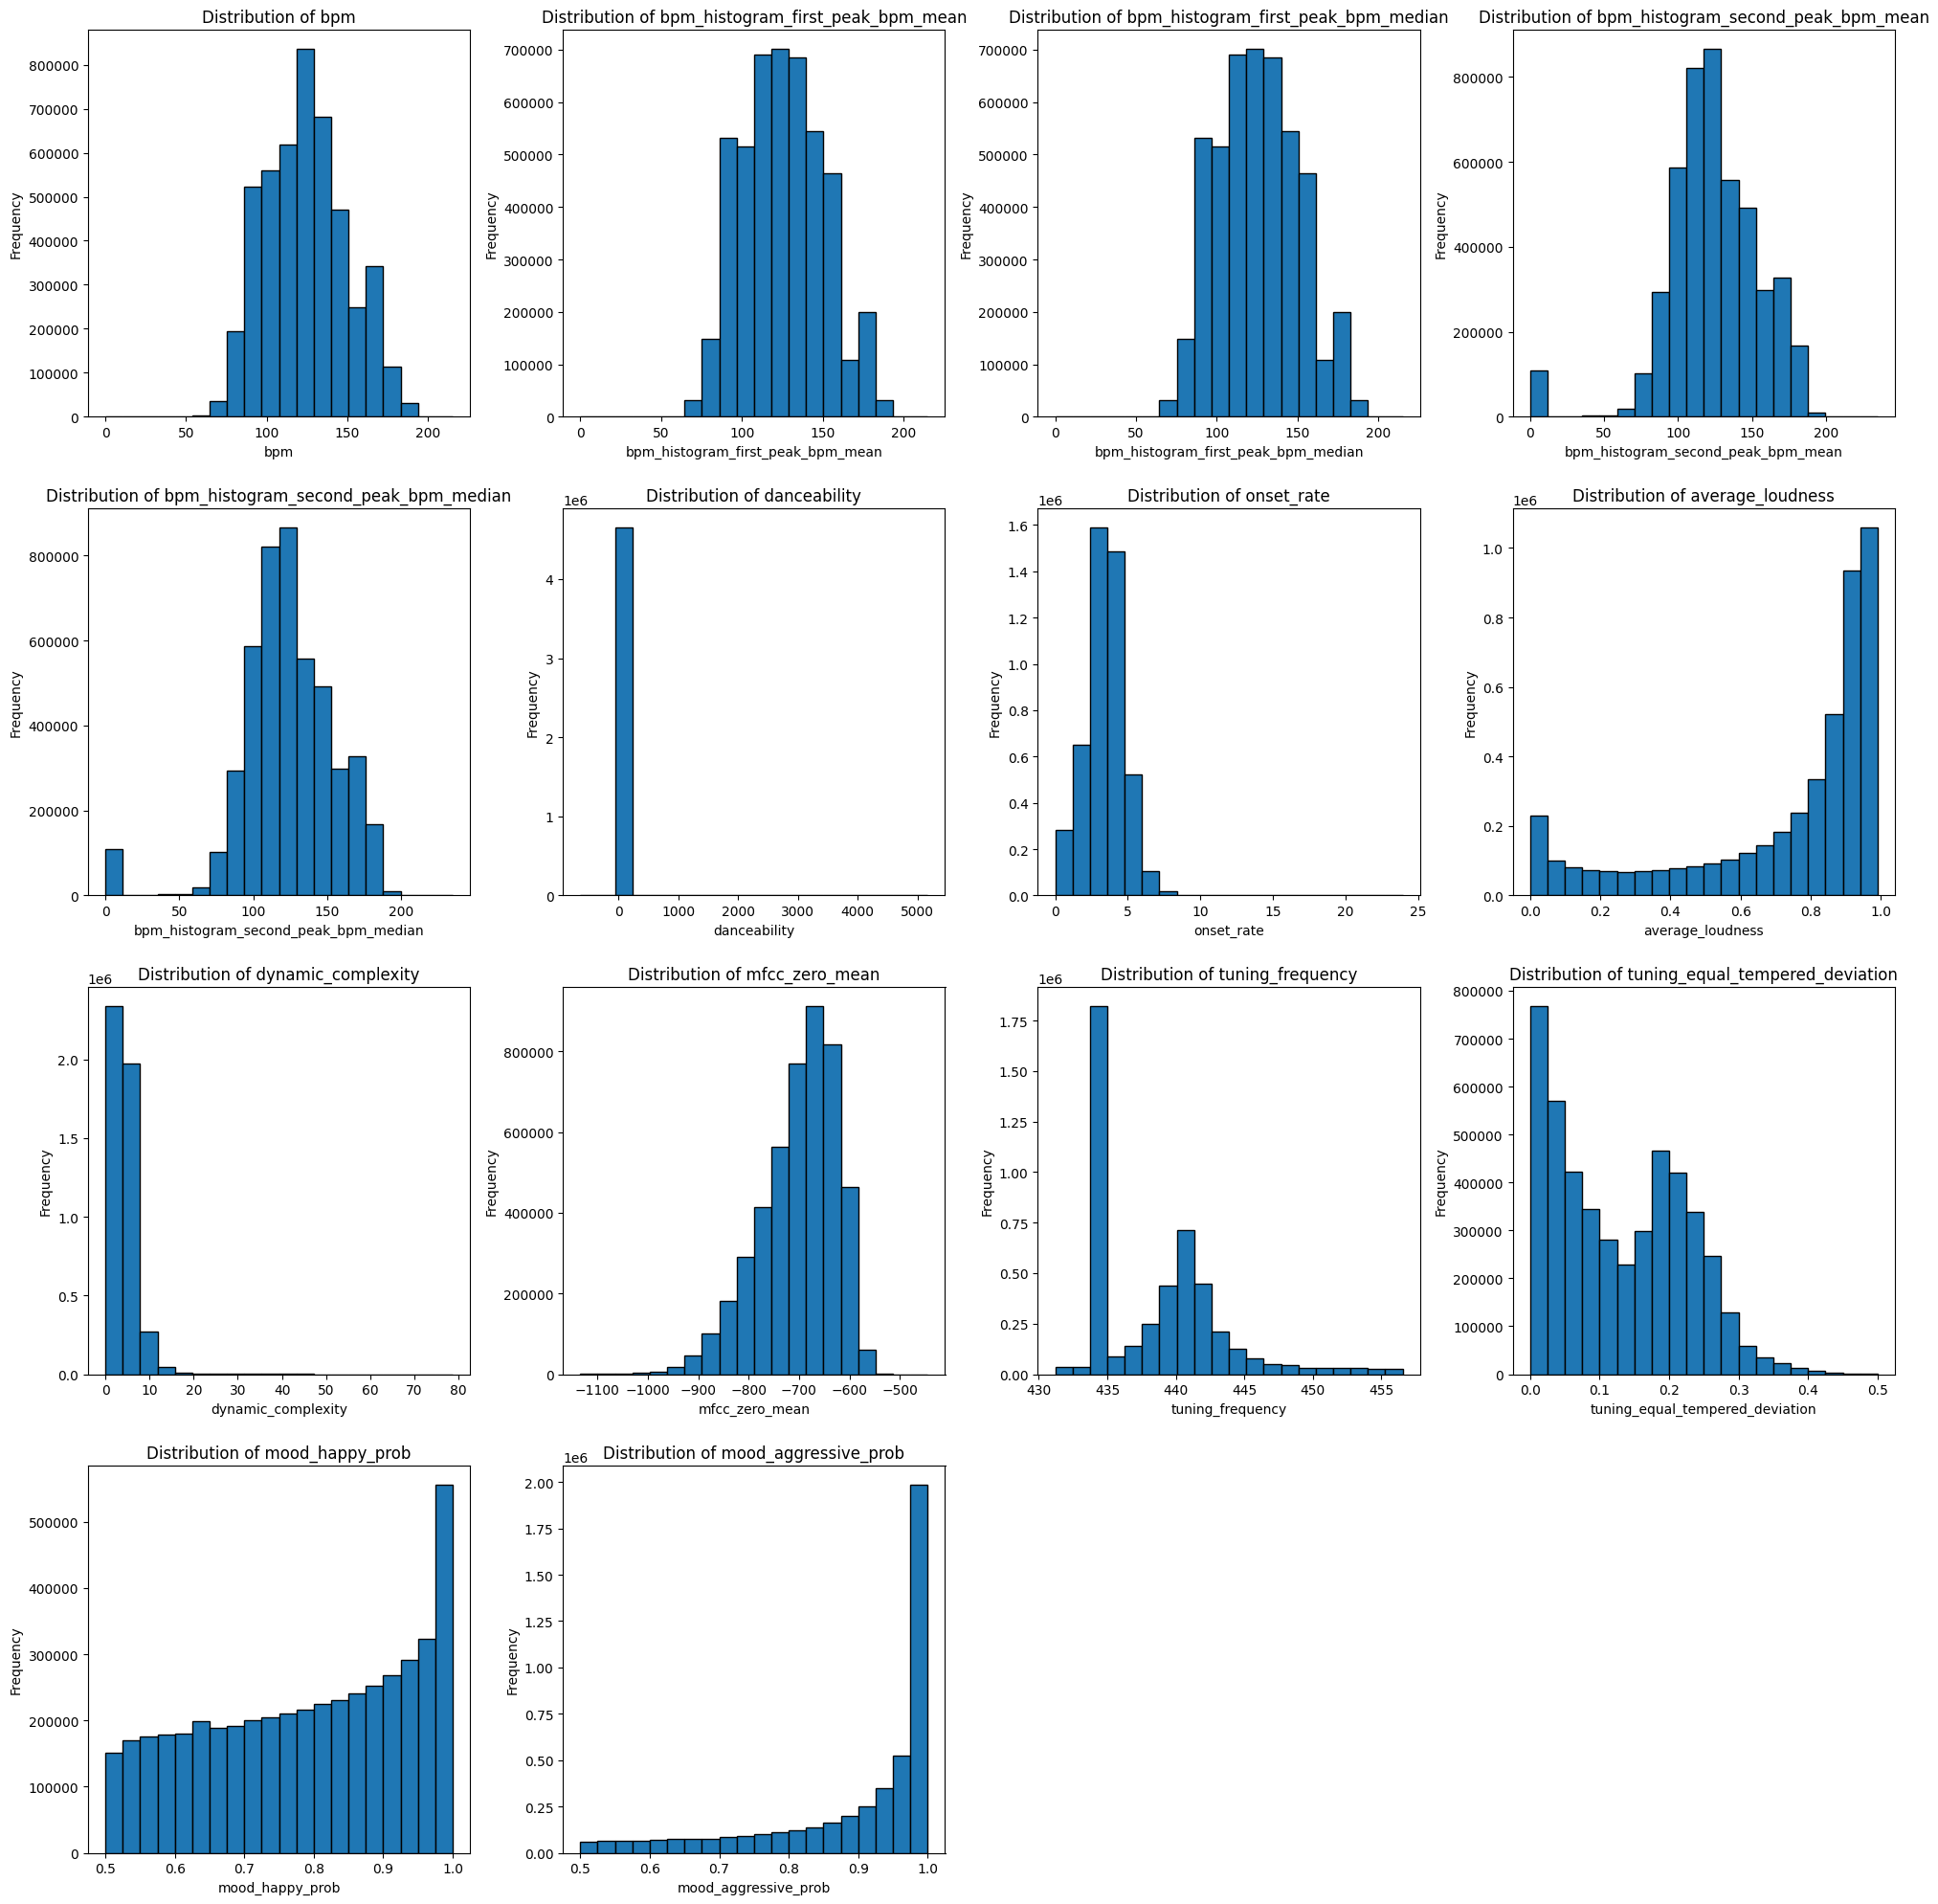

In [67]:
num_cols = len(numeric_cols)
n_cols = 4
n_rows = 4

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [68]:
df.describe()

,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,mfcc_zero_mean,tuning_frequency,tuning_equal_tempered_deviation,mood_happy_prob,mood_aggressive_prob
count,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06,4.657526e+06
mean,1.239823e+02,1.243839e+02,1.243839e+02,1.242392e+02,1.242392e+02,1.152619e+00,3.428675e+00,7.273701e-01,4.444355e+00,-7.019374e+02,4.386020e+02,1.299202e-01,7.904982e-01,8.982364e-01
std,2.491403e+01,2.483791e+01,2.483791e+01,3.211548e+01,3.211548e+01,2.569228e+00,1.323059e+00,2.893301e-01,2.573701e+00,7.631593e+01,4.731692e+00,9.417623e-02,1.488633e-01,1.309371e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.389771e+02,0.000000e+00,3.464500e-09,0.000000e+00,-1.134098e+03,4.311939e+02,0.000000e+00,5.000000e-01,5.000000e-01
25%,1.046405e+02,1.050000e+02,1.050000e+02,1.080000e+02,1.080000e+02,9.989684e-01,2.629219e+00,6.135966e-01,2.912047e+00,-7.480400e+02,4.341931e+02,4.145746e-02,6.641319e-01,8.459509e-01
50%,1.231623e+02,1.230000e+02,1.230000e+02,1.230000e+02,1.230000e+02,1.114964e+00,3.463930e+00,8.628480e-01,3.922635e+00,-6.888065e+02,4.387310e+02,1.190218e-01,8.068994e-01,9.600367e-01
75%,1.400357e+02,1.400000e+02,1.400000e+02,1.440000e+02,1.440000e+02,1.254543e+00,4.284003e+00,9.369724e-01,5.284657e+00,-6.445376e+02,4.412726e+02,2.060806e-01,9.256572e-01,9.948211e-01
max,2.153320e+02,2.150000e+02,2.150000e+02,2.350000e+02,2.350000e+02,5.173636e+03,2.393871e+01,9.906840e-01,7.868979e+01,-4.445597e+02,4.565703e+02,5.000000e-01,1.000000e+00,1.000000e+00


Having 0 for bpm related features seems incorrect so will drop those

In [69]:
len(df[df['bpm_histogram_second_peak_bpm_mean'] < 20])

108092

In [70]:
df = df[df['bpm'] >= 20]
df = df[df['bpm_histogram_first_peak_bpm_mean'] >= 20]
df = df[df['bpm_histogram_first_peak_bpm_median'] >= 20]
df = df[df['bpm_histogram_second_peak_bpm_mean'] >= 20]
df = df[df['bpm_histogram_second_peak_bpm_median'] >= 20]

Based on the description, danceability should be between 0 and around 3: "danceability (real) - the danceability value. Normal values range from 0 to ~3. The higher, the more danceable."

In [71]:
df['danceability'].describe()

count    4.549434e+06
mean     1.147741e+00
std      2.455565e+00
min     -3.040482e+01
25%      9.969573e-01
50%      1.112039e+00
75%      1.249437e+00
max      5.173636e+03
Name: danceability, dtype: float64

In [72]:
len(df[df['danceability'] < 0])

12

In [73]:
len(df[df['danceability'] > 3])

1585

In [74]:
df = df[df['danceability'].between(0, 3)]

MFCCs are:

"log-scaled spectral features
often centered around negative values after processing
frequently mean-normalized (“zero_mean”) - shifts distribution below 0,
not bounded to any fixed range"

In [75]:
df['mfcc_zero_mean'].describe()

count    4.547837e+06
mean    -7.021489e+02
std      7.643829e+01
min     -1.134098e+03
25%     -7.486428e+02
50%     -6.890286e+02
75%     -6.444850e+02
max     -4.445597e+02
Name: mfcc_zero_mean, dtype: float64

In [76]:
df['tuning_equal_tempered_deviation'].describe()

count    4.547837e+06
mean     1.292263e-01
std      9.411772e-02
min      0.000000e+00
25%      4.091489e-02
50%      1.173575e-01
75%      2.056333e-01
max      5.000000e-01
Name: tuning_equal_tempered_deviation, dtype: float64

Check the distributions again

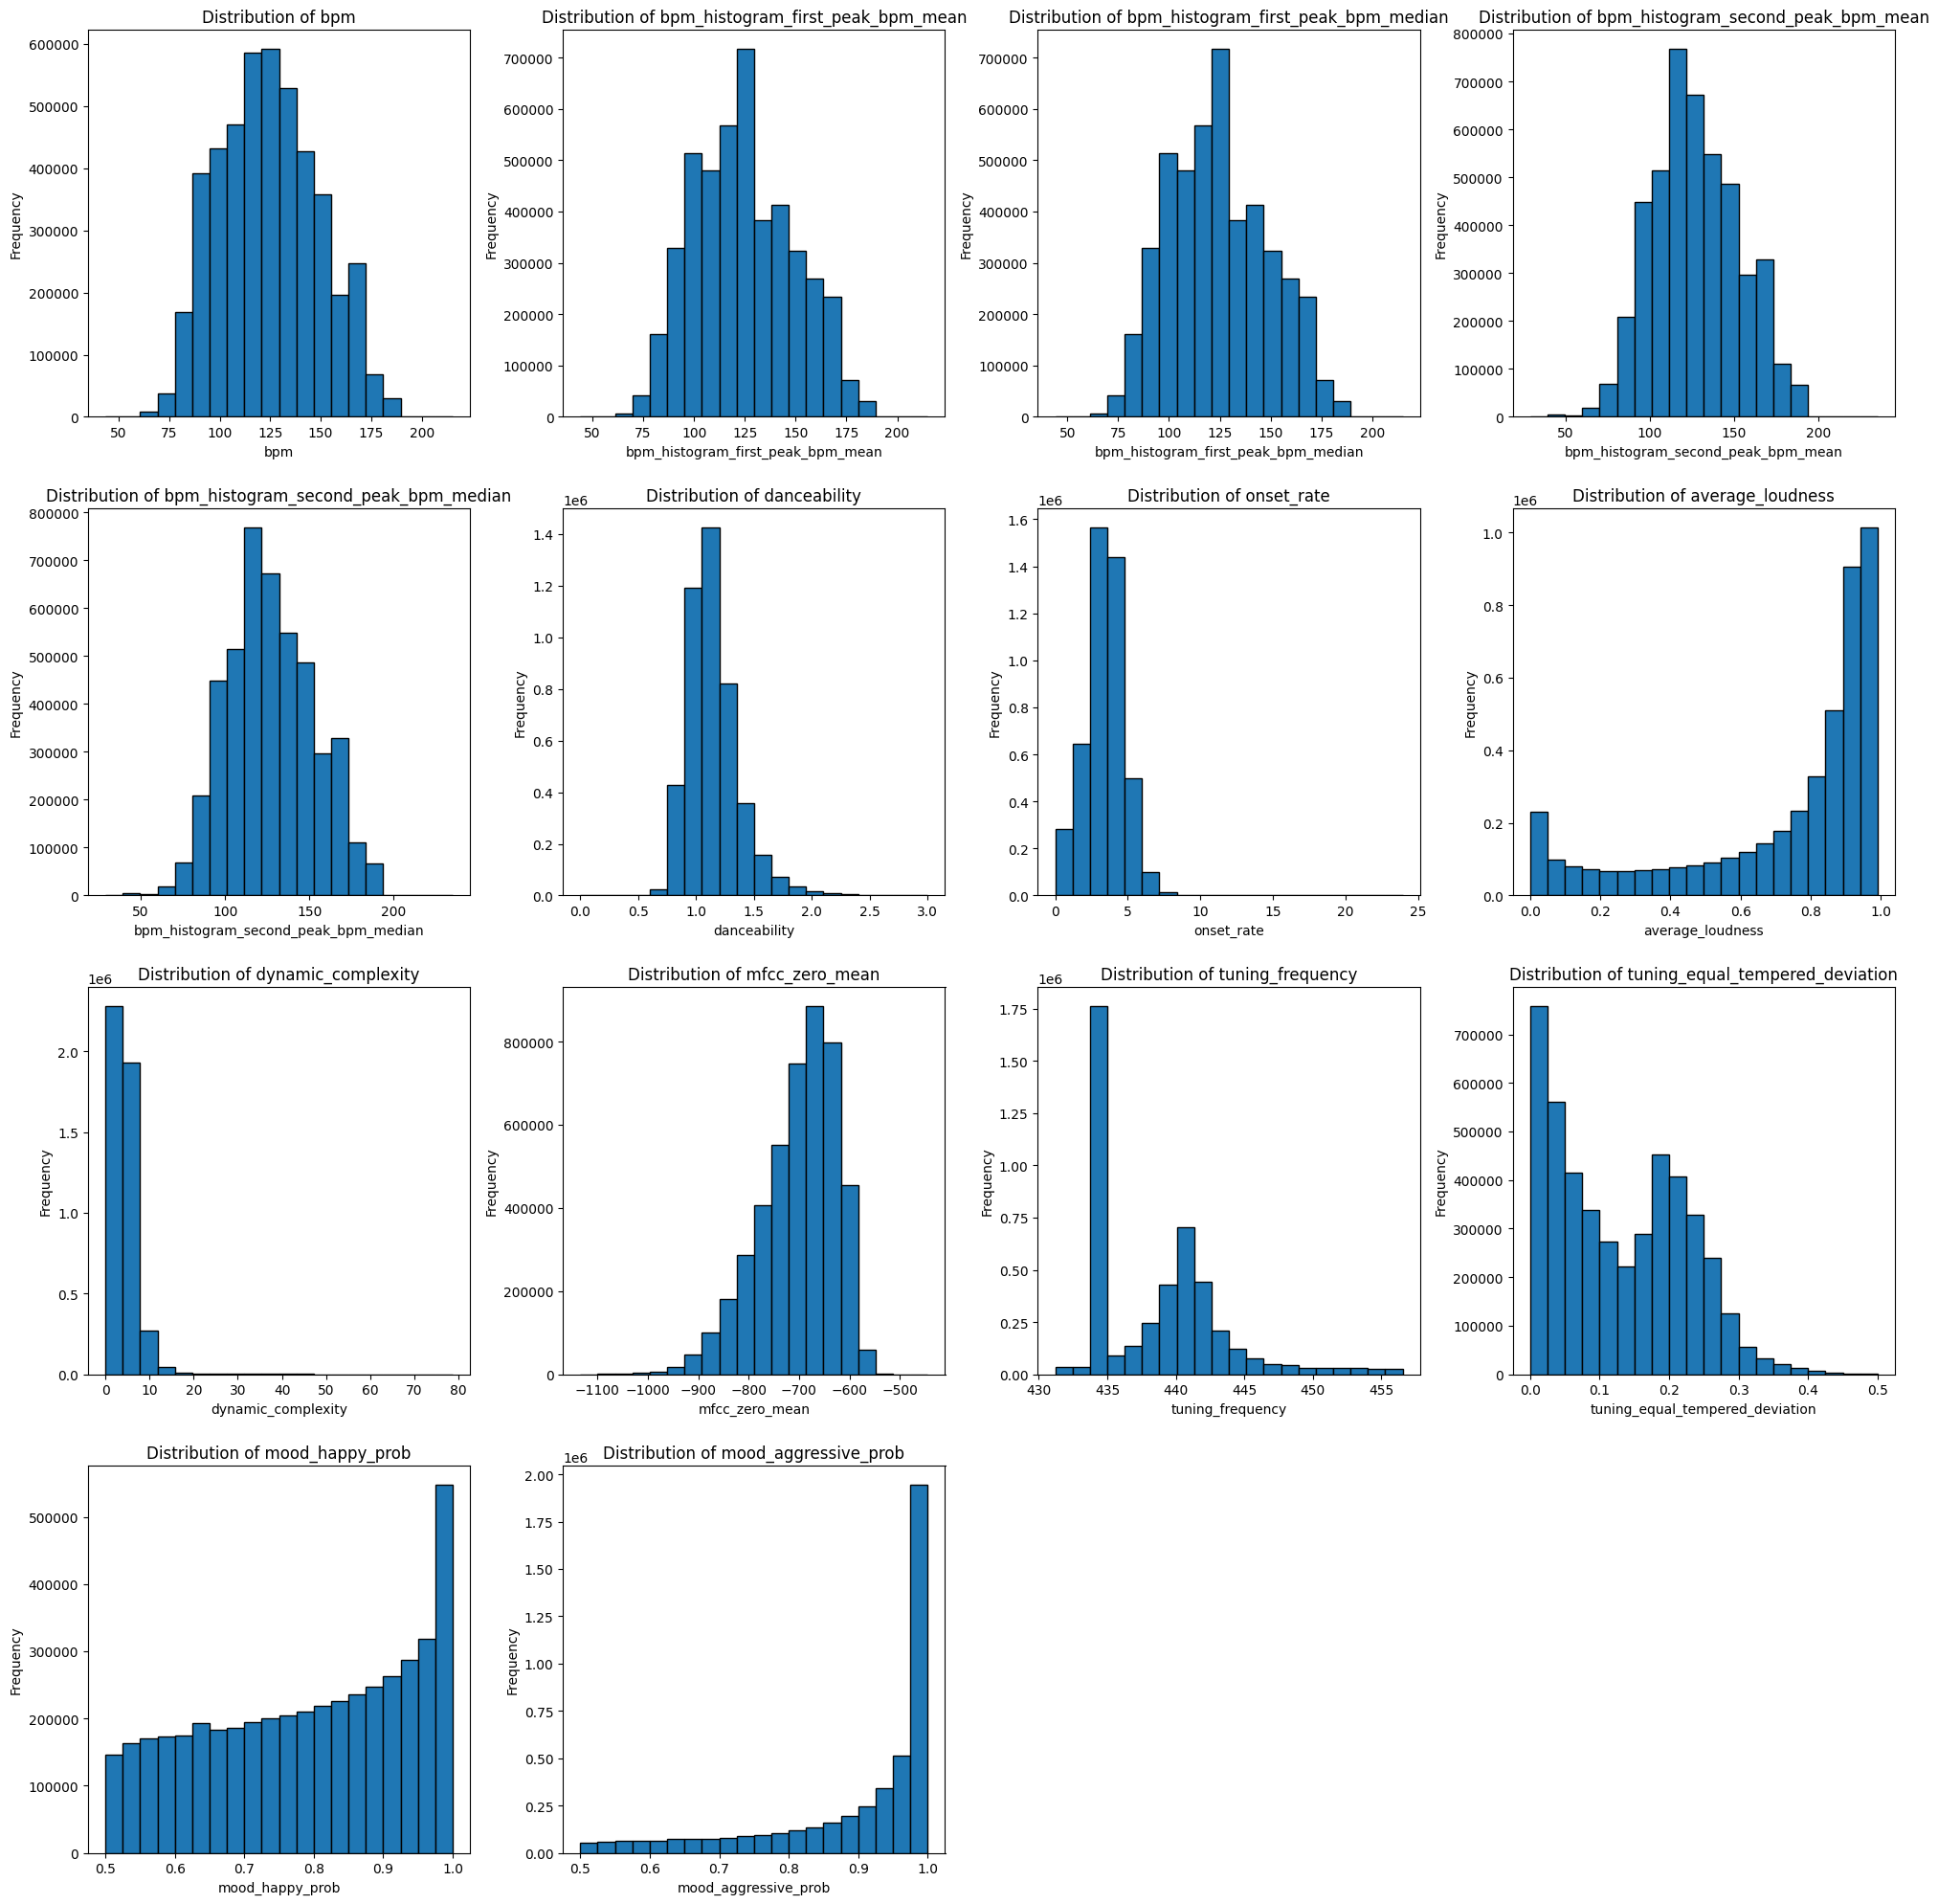

In [77]:
num_cols = len(numeric_cols)
n_cols = 4
n_rows = 4

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 4547837 entries, 2 to 5598785
Data columns (total 29 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob                

View the genre value counts

In [ ]:
from IPython.display import display, HTML
from itables import show

# 1. Temporarily allow pandas to output all rows without cutting them off
with pd.option_context('display.max_rows', None):
    # 2. Convert your value counts to an HTML table string
    html_table = df['genre'].value_counts().to_frame().to_html()

# 3. Put that table inside a scrollable box (400 pixels high)
scroll_box = f"""
<div style="max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;">
    {html_table}
</div>
"""

# 4. Force Jupyter to render the scrollable box
display(HTML(scroll_box))

,count
genre,
electronic,351374
rock,320581
classical,205574
jazz,183033
pop,163366
hip hop,128465
experimental,92984
ambient,82206
folk,76639


In [82]:
genre_counts = df['genre'].value_counts().to_frame().reset_index()

In [83]:
genre_counts

,genre,count
0,electronic,351374
1,rock,320581
2,classical,205574
3,jazz,183033
4,pop,163366
...,...,...
8881,swingbeat,1
8882,context/hidden-track,1
8883,raaga nataguru,1
8884,moldova,1


Do Feature engineering of genre column

In [ ]:
from rapidfuzz import process

Preprocess the genre column to clean invalid or missing entries

Handle missing/empty values and strip whitespaces

In [ ]:
df["genre"] = df["genre"].fillna("").astype(str).str.strip()

Define main genres and sub genres

In [ ]:
main_genres = {
    "Electronic": ["electronic", "edm", "techno", "house", "downtempo", "idm", "synthpop", "synth-wave", 
                   "electro", "ambient techno", "chillwave", "electronica", "vaporwave", "experimental electronic", 
                   "electro-acoustic", "progressive electronic", "chiptune", "gabber", "future funk"],
    "Rock": ["rock", "classic rock", "hard rock", "indie rock", "progressive rock", "psychedelic rock", 
             "alternative rock", "garage rock", "space rock", "grunge"],
    "Classical": ["classical", "modern classical", "baroque", "film composer", "composer", "symphony", 
                  "chamber music", "string quartet", "symphonic prog"],
    "Jazz": ["jazz", "bebop", "vocal jazz", "smooth jazz", "jazz fusion", "jazz-funk", "cool jazz", 
             "free jazz", "gypsy jazz", "fusion"],
    "Pop": ["pop", "indie pop", "pop soul", "pop rock", "synth-pop", "dance-pop", "psychedelic pop"],
    "Hip Hop": ["hip hop", "rap", "lo-fi hip hop", "gangsta rap", "underground hip hop", "pop rap", 
                "trap", "conscious hip hop"],
    "Experimental": ["experimental", "noise", "avant-garde", "sound art", "dungeon synth", "ambient experimental"],
    "Ambient": ["ambient", "dark ambient", "space ambient", "cinematic classical"],
    "Folk": ["folk", "indie folk", "folk pop", "folk rock", "neofolk", "folktronica"],
    "Punk": ["punk", "punk rock", "pop punk", "post-punk", "hardcore punk", "emo punk"],
    "Alternative Rock": ["alternative rock", "grunge", "noise rock", "shoegaze", "stoner rock", "experimental rock"],
    "Indie Rock": ["indie rock", "alternative indie", "dream pop", "math rock"],
    "Metal": ["metal", "doom metal", "death metal", "black metal", "thrash metal", "progressive metal"],
    "Country": ["country", "alt-country", "country pop", "country rock", "bluegrass", "americana"],
    "Soundtrack": ["soundtrack", "film", "anime", "vgm", "video game music", "musical", "cinematic"],
    "R&B": ["r&b", "soul and r&b", "contemporary r&b", "funk", "neo-soul"],
    "Reggae": ["reggae", "roots reggae", "dub", "dancehall", "ska"],
    "Blues": ["blues", "country blues", "blues rock", "soul blues", "electronic blues"],
    "Techno": ["techno", "minimal techno", "acid techno", "electro-techno"],
    "Heavy Metal": ["heavy metal", "viking metal", "doom metal", "progressive metal"],
    "Soul": ["soul", "neo soul", "southern soul"],
    "House": ["house", "progressive house", "electro house", "deep house", "tech house"],
    "Dance": ["dance", "dance pop", "dance rock", "freestyle"],
    "Easy Listening": ["easy listening", "lounge", "chillout"]
}

Define functions to process genres

In [ ]:
def map_main_genre(genre, main_genres):
    """
    Match genre to a main category using RapidFuzz for efficient string comparison.
    """
    for main_genre, subgenres in main_genres.items():
        match = process.extractOne(genre.lower(), subgenres, score_cutoff=85)
        if match:
            return main_genre  # Return main genre if match found
    return "Other"  # Default fallback

def map_sub_genre(genre, main_genres):
    """
    Returns subgenre directly if a valid match is identified, otherwise 'Other'.
    """
    for main_genre, subgenres in main_genres.items():
        match = process.extractOne(genre.lower(), subgenres, score_cutoff=85)
        if match:
            return match[0]  # Return matched subgenre
    return "Other"

def process_batch(df_batch, main_genres):
    """
    Processes a batch of rows and maps main_genre and sub_genre in parallel.
    """
    df_batch['main_genre'] = df_batch['genre'].apply(lambda g: map_main_genre(g, main_genres))
    df_batch['sub_genre'] = df_batch['genre'].apply(lambda g: map_sub_genre(g, main_genres))
    return df_batch


Process as batches

In [ ]:
import os
# Configure batch size and directory for batch files
batch_size = 100000
output_dir = "processed_batches"  # Directory to store batch files
os.makedirs(output_dir, exist_ok=True) 

# Process each batch and save to separate files
num_batches = len(df) // batch_size + 1
for batch_num in range(num_batches):
    print(f"Processing batch {batch_num + 1} / {num_batches}...")
    start_row = batch_num * batch_size
    end_row = min(start_row + batch_size, len(df))
    batch = df.iloc[start_row:end_row]
    
    # Process the batch
    result_batch = process_batch(batch, main_genres)
    
    # Save the batch as a separate file
    batch_file = os.path.join(output_dir, f"batch_{batch_num + 1}.csv")
    result_batch.to_csv(batch_file, index=False)
    print(f"Batch {batch_num + 1} saved to {batch_file}.")

print("Processing complete")

Merge all batch files to single dataframe

In [ ]:
import glob

output_dir = "processed_batches"  # Directory to store batch files
os.makedirs(output_dir, exist_ok=True) 

# Merge all batch files into a single DataFrame
batch_files = glob.glob(os.path.join(output_dir, "batch_*.csv"))
merged_df = pd.concat([pd.read_csv(batch_file) for batch_file in batch_files], ignore_index=True)

# Save the merged DataFrame
merged_df.to_csv("data/genre_processed_output.csv", index=False)
print("All batches merged into processed_output.csv.")

Load in the processed genre data

In [ ]:
df = pd.read_csv('data/genre_processed_output.csv')

In [38]:
df.shape

(4547837, 31)

In [39]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

In [7]:
df.head(3000000)

,mbid,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,...,mood_acoustic,mood_electronic,mood_party,voice_gender,timbre,tonal_atonal,voice_instrumental,genre,main_genre,sub_genre
0,00000910-c0d0-4792-827c-9a31719161c3,132.114716,133.0,133.0,117.0,117.0,0.963751,2.697139,0.939739,2.026948,...,not_acoustic,not_electronic,not_party,female,dark,atonal,voice,death metal,Metal,death metal
1,000009a8-34f1-4c58-a8de-1d99809cd626,95.068558,96.0,96.0,88.0,88.0,1.064906,2.686261,0.687424,3.005937,...,acoustic,not_electronic,not_party,female,bright,tonal,voice,progressive metal,Metal,progressive metal
2,00000ab7-3cbf-4c8c-954f-7239de7821c5,89.911079,91.0,91.0,120.0,120.0,1.050370,5.002318,0.647487,4.984218,...,not_acoustic,electronic,party,male,dark,atonal,voice,experimental electronic,Electronic,experimental electronic
3,00000baf-9215-483a-8900-93756eaf1cfc,97.024086,98.0,98.0,91.0,91.0,1.348803,3.769673,0.948725,2.141814,...,not_acoustic,electronic,not_party,male,dark,tonal,instrumental,german,Other,Other
4,000011ea-a75a-4b4a-9ab7-e8b3c6c64705,99.880089,99.0,99.0,94.0,94.0,0.963569,3.208771,0.312500,8.135631,...,acoustic,not_electronic,not_party,female,dark,atonal,voice,folk,Folk,folk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,ca8dfd3d-0738-4adf-acc9-981fb0ec1dd1,114.644440,115.0,115.0,123.0,123.0,0.884310,2.279065,0.002332,8.031928,...,not_acoustic,electronic,not_party,female,bright,tonal,instrumental,dark ambient,Experimental,ambient experimental
2999996,ca8dfd65-85d2-4a93-b1d0-3b375ccf4d5d,119.800598,120.0,120.0,112.0,112.0,0.875668,2.774591,0.110098,7.664715,...,acoustic,not_electronic,not_party,female,bright,atonal,voice,pop,Electronic,synthpop
2999997,ca8dfd7c-6d53-44dc-8620-c9417464c76b,119.675842,120.0,120.0,115.0,115.0,0.847664,3.125438,0.370043,6.136026,...,acoustic,electronic,not_party,male,dark,tonal,instrumental,post-classical,Classical,classical
2999998,ca8e04ba-933b-4ee3-b906-cd5368750ecd,90.015320,91.0,91.0,120.0,120.0,0.958459,2.379226,0.373009,5.276371,...,acoustic,not_electronic,not_party,female,bright,tonal,instrumental,pop rock,Rock,rock


In [8]:
df['main_genre'].value_counts()

main_genre
Electronic          989396
Other               860460
Rock                846829
Classical           299607
Metal               266171
Jazz                248277
Hip Hop             197972
Pop                 177538
Punk                119940
Folk                104295
Soundtrack           93399
Country              87465
Reggae               73461
Blues                57792
Experimental         55924
R&B                  29332
Easy Listening       18495
Alternative Rock      9987
Dance                 5154
Techno                3704
Ambient               1701
Soul                   542
Indie Rock             313
Heavy Metal             68
House                   15
Name: count, dtype: int64

Correct misclassifed pop to electronic

In [40]:
def correct_pop_classifications(row):
    """
    Correct main_genre to 'Pop' and sub_genre to 'pop' if original genre is 'pop' (case-insensitive).
    """
    if row['genre'].strip().lower() == 'pop':  # If genre is exactly 'pop'
        return 'Pop'
    return row['main_genre']  # Keep existing classification otherwise

def correct_pop_subgenre(row):
    """
    Set sub_genre to 'pop' if original genre is exactly 'pop'.
    """
    if row['genre'].strip().lower() == 'pop':  # If genre is exactly 'pop'
        return 'pop'
    return row['sub_genre']  # Keep existing subgenre otherwise

# Apply corrections to all rows
df['main_genre'] = df.apply(correct_pop_classifications, axis=1)
df['sub_genre'] = df.apply(correct_pop_subgenre, axis=1)

# Verify the corrections
print(df[df['genre'].str.strip().str.lower() == 'pop'][['genre', 'main_genre', 'sub_genre']].head(50))

     genre main_genre sub_genre
38     pop        Pop       pop
50     pop        Pop       pop
120    pop        Pop       pop
137    pop        Pop       pop
150    pop        Pop       pop
214    pop        Pop       pop
266    pop        Pop       pop
267    pop        Pop       pop
325    pop        Pop       pop
337    pop        Pop       pop
387    pop        Pop       pop
388    pop        Pop       pop
412    pop        Pop       pop
415    pop        Pop       pop
445    pop        Pop       pop
542    pop        Pop       pop
599    pop        Pop       pop
635    pop        Pop       pop
655    pop        Pop       pop
672    pop        Pop       pop
686    pop        Pop       pop
693    pop        Pop       pop
730    pop        Pop       pop
741    pop        Pop       pop
752    pop        Pop       pop
764    pop        Pop       pop
767    pop        Pop       pop
772    pop        Pop       pop
851    pop        Pop       pop
875    pop        Pop       pop
897    p

In [41]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4547837 entries, 0 to 4547836
Data columns (total 31 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob           

In [6]:
df['key_key'].value_counts()

key_key
A     591896
F     551511
C     532600
D     523627
A#    517375
G     408760
E     364860
D#    235247
C#    234875
G#    214499
B     191296
F#    181291
Name: count, dtype: int64

Decide to one hot encode keys

In [42]:
df = pd.get_dummies(df, columns = ['key_key'], dtype = int)

Convert binary variables to 0 and 1

In [45]:
df['key_scale'].value_counts()

key_scale
1    2550087
0    1997750
Name: count, dtype: int64

In [44]:
df['key_scale'] = df['key_scale'].map({'major' : 1, 'minor' : 0})

In [46]:
df['mood_happy'].value_counts()

mood_happy
not_happy    3304738
happy        1243099
Name: count, dtype: int64

In [47]:
df['mood_happy'] = df['mood_happy'].map({'happy' : 1, 'not_happy' : 0})

In [48]:
df['mood_sad'].value_counts()

mood_sad
not_sad    3057626
sad        1490211
Name: count, dtype: int64

In [49]:
df['mood_sad'] = df['mood_sad'].map({'sad' : 1, 'not_sad' : 0})

In [50]:
df['mood_relaxed'].value_counts()

mood_relaxed
relaxed        3052660
not_relaxed    1495177
Name: count, dtype: int64

In [51]:
df['mood_relaxed'] = df['mood_relaxed'].map({'relaxed' : 1, 'not_relaxed' : 0})

In [52]:
df['mood_aggressive'].value_counts()

mood_aggressive
not_aggressive    3497241
aggressive        1050596
Name: count, dtype: int64

In [53]:
df['mood_aggressive'] = df['mood_aggressive'].map({'aggressive' : 1, 'not_aggressive' : 0})

In [54]:
df['mood_acoustic'].value_counts()

mood_acoustic
not_acoustic    2936238
acoustic        1611599
Name: count, dtype: int64

In [55]:
df['mood_acoustic'] = df['mood_acoustic'].map({'acoustic' : 1, 'not_acoustic' : 0})

In [56]:
df['mood_electronic'].value_counts()

mood_electronic
electronic        2534752
not_electronic    2013085
Name: count, dtype: int64

In [57]:
df['mood_electronic'] = df['mood_electronic'].map({'electronic' : 1, 'not_electronic' : 0})

In [58]:
df['mood_party'].value_counts()

mood_party
not_party    2979604
party        1568233
Name: count, dtype: int64

In [59]:
df['mood_party'] = df['mood_party'].map({'party' : 1, 'not_party' : 0})

In [60]:
df['voice_gender'].value_counts()

voice_gender
female    2664761
male      1883076
Name: count, dtype: int64

In [61]:
df['voice_gender'] = df['voice_gender'].map({'female' : 1, 'male' : 0})

In [62]:
df['timbre'].value_counts()

timbre
dark      2466328
bright    2081509
Name: count, dtype: int64

In [63]:
df['timbre'] = df['timbre'].map({'bright' : 1, 'dark' : 0})

In [67]:
df['tonal_atonal'].value_counts()

tonal_atonal
0    2594896
1    1952941
Name: count, dtype: int64

In [68]:
df['tonal_atonal'].isna().sum()

np.int64(0)

In [66]:
df['tonal_atonal'] = df['tonal_atonal'].map({'tonal' : 1, 'atonal' : 0})

In [69]:
df['voice_instrumental'].value_counts()

voice_instrumental
instrumental    2284191
voice           2263646
Name: count, dtype: int64

In [70]:
df['voice_instrumental'] = df['voice_instrumental'].map({'voice' : 1, 'instrumental' : 0})

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4547837 entries, 0 to 4547836
Data columns (total 42 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_scale                             int64  
 14  mood_happy_prob                       float64
 15  mood_aggressive_prob      

Don't need mbid or original genre columns

In [73]:
df.drop(columns = ['mbid', 'genre'], inplace = True)

Save as csv

In [74]:
df.to_csv('data/genre_cleaned.csv', index = False)